In [7]:
import zipfile
with zipfile.ZipFile("E-commerce.zip", "r") as z:
  z.extractall()
  print(z.namelist())

['Amazon Sale Report.csv', 'Cloud Warehouse Compersion Chart.csv', 'Expense IIGF.csv', 'International sale Report.csv', 'May-2022.csv', 'P  L March 2021.csv', 'Sale Report.csv']


In [8]:
import pandas as pd

df = pd.read_csv("Amazon Sale Report.csv",encoding="latin1")
print(df.shape)
print(df.head())



/tmp/ipykernel_4547/3827147667.py:3: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Amazon Sale Report.csv",encoding="latin1")


(128975, 24)
   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon      Amazon.in          Expedited  JNE3371    JNE3371-KR-XL   
3   Merchant      Amazon.in           Standard    J0341       J0341-DR-L   
4     Amazon      Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL   

        Category  ... currency  Amount    ship-city   ship-state  \
0            Set  ...  

In [9]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [10]:
print(df.columns.tolist())

['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']


In [11]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [12]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [13]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [14]:
df_clean = df.dropna(subset=['Amount','ship-state'])
print(df_clean.shape)

(121149, 24)


In [15]:
category_sales = df_clean.groupby('Category')['Amount'].sum().sort_values(ascending=False).head(10)
print("Top 10 Categories by Sales:")
print(category_sales)

Top 10 Categories by Sales:
Category
Set              39195176.03
kurta            21291538.70
Western Dress    11215337.69
Top               5346812.30
Ethnic Dress       791217.66
Blouse             458408.18
Bottom             150667.98
Saree              123933.76
Dupatta               915.00
Name: Amount, dtype: float64


In [16]:
import matplotlib.pyplot as plt

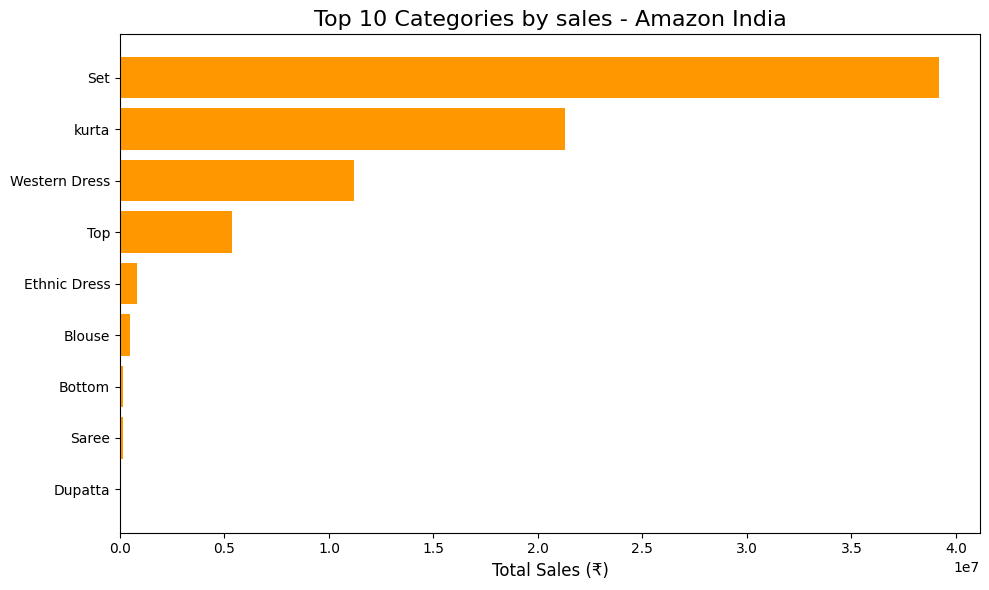

In [17]:
plt.figure(figsize=(10,6))
plt.barh(category_sales.index[::-1], category_sales.values[::-1], color='#FF9800')
plt.title('Top 10 Categories by sales - Amazon India', fontsize=16)
plt.xlabel('Total Sales (₹)', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
state_sales = df_clean.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)
print("Top 10 States by Sales:")
print(state_sales)

Top 10 States by Sales:
ship-state
MAHARASHTRA       13335534.14
KARNATAKA         10481114.37
TELANGANA          6916615.65
UTTAR PRADESH      6816642.08
TAMIL NADU         6515650.11
DELHI              4235215.97
KERALA             3830227.58
WEST BENGAL        3507880.44
ANDHRA PRADESH     3219831.72
HARYANA            2882092.99
Name: Amount, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

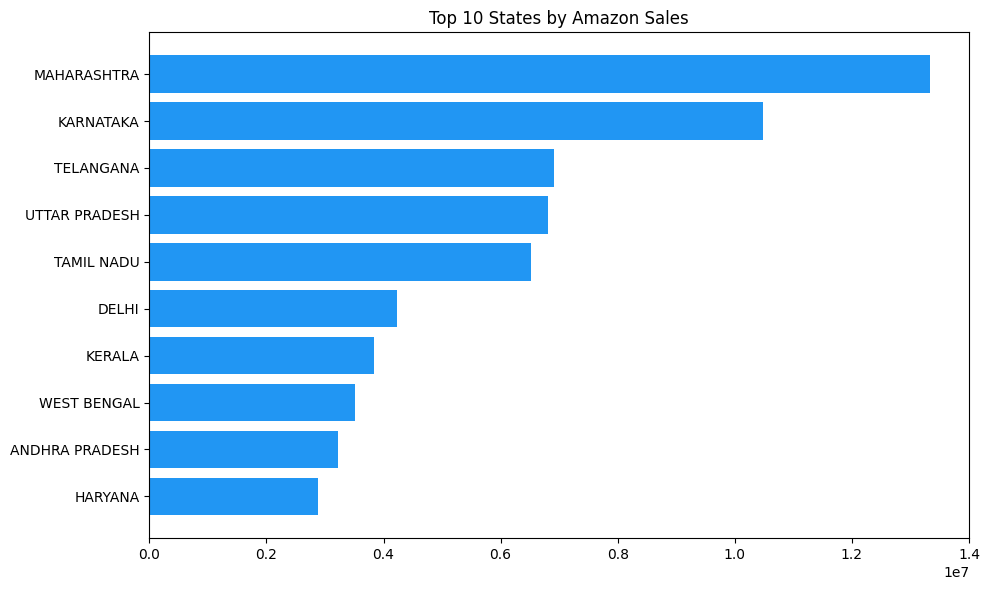

In [19]:
plt.figure(figsize=(10,6))
plt.barh(state_sales.index[::-1], state_sales.values[::-1], color='#2196F3')
plt.title('Top 10 States by Amazon Sales', fontsize=12)
plt.tight_layout()
plt.show

In [20]:
status_counts = df_clean['Status'].value_counts()
print("Order Status breakdown:")
print(status_counts)

Order Status breakdown:
Status
Shipped                          77580
Shipped - Delivered to Buyer     28754
Cancelled                        10761
Shipped - Returned to Seller      1947
Shipped - Picked Up                973
Pending                            656
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

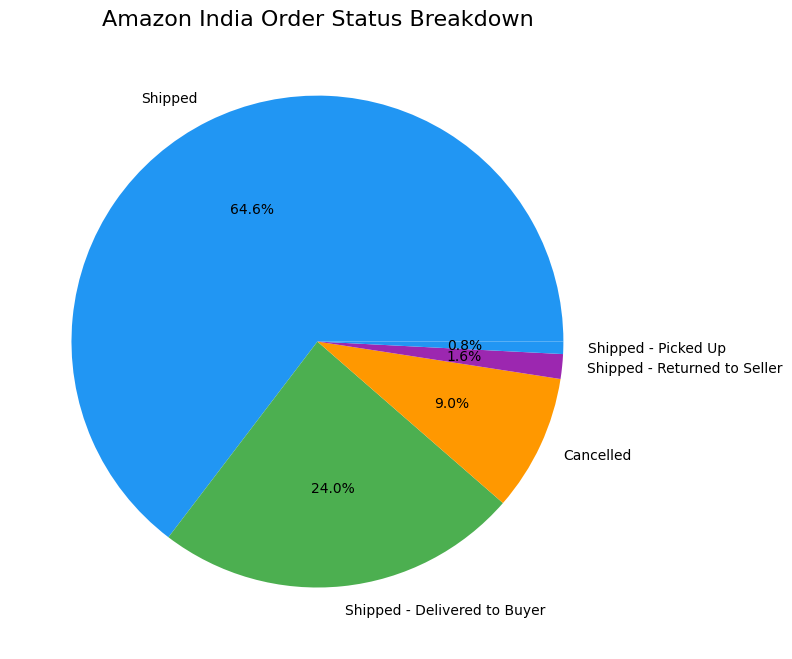

In [21]:
top_status = status_counts.head(5)

plt.figure(figsize=(8,8))
plt.pie(top_status.values, labels=top_status.index, autopct='%1.1f%%',colors=['#2196F3','#4CAF50','#FF9800','#9C27B0'])
plt.title('Amazon India Order Status Breakdown', fontsize=16)
plt.tight_layout()
plt.show

In [23]:
print("=" * 50)
print("     AMAZON INDIA SALES ANALYSIS SUMMARY")
print("=" * 50)
print()
print(f"📦 Total Orders: {len(df_clean):,}")
print()
print(f"🏆 Top Category: {category_sales.index[0]}")
print(f"   Revenue: ₹{category_sales.iloc[0]:,.0f}")
print()
print(f"📍 Top State: Maharashtra")
print(f"   Revenue: ₹{state_sales.iloc[0]:,.0f}")
print()
print(f"✅ Delivered Orders: {28754:,}")
print(f"❌ Cancelled Orders: {10761:,} ({10761/len(df_clean)*100:.1f}%)")
print("=" * 50)


     AMAZON INDIA SALES ANALYSIS SUMMARY

📦 Total Orders: 121,149

🏆 Top Category: Set
   Revenue: ₹39,195,176

📍 Top State: Maharashtra
   Revenue: ₹13,335,534

✅ Delivered Orders: 28,754
❌ Cancelled Orders: 10,761 (8.9%)
